In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

df = pd.read_csv('cartoon_popularity_data.csv')

Part 1 Exploratory Data Analysis

Task 1.1 Basic Exploration

In [2]:
print(df.shape)
print(df.dtypes)
display(df.describe())
print(df.isnull().sum())

(10000, 5)
Character                         str
Country                           str
Popularity_Score                  str
Avg_Episodes_Watched_Per_Year     str
Merchandise_Revenue_MillionUSD    str
dtype: object


,Character,Country,Popularity_Score,Avg_Episodes_Watched_Per_Year,Merchandise_Revenue_MillionUSD
count,10000,9553,9558,9933,10000
unique,50,41,9488,492,10000
top,Doraemon,Australia,Unknown,13,3.949924724368964
freq,929,430,71,93,1


Character                           0
Country                           447
Popularity_Score                  442
Avg_Episodes_Watched_Per_Year      67
Merchandise_Revenue_MillionUSD      0
dtype: int64


Task 1.2 Data Visualization

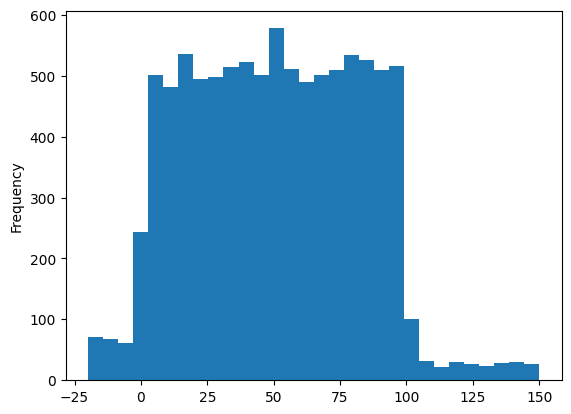

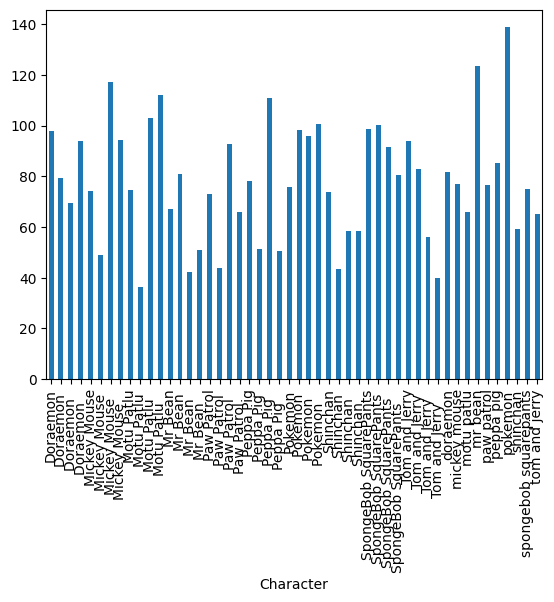

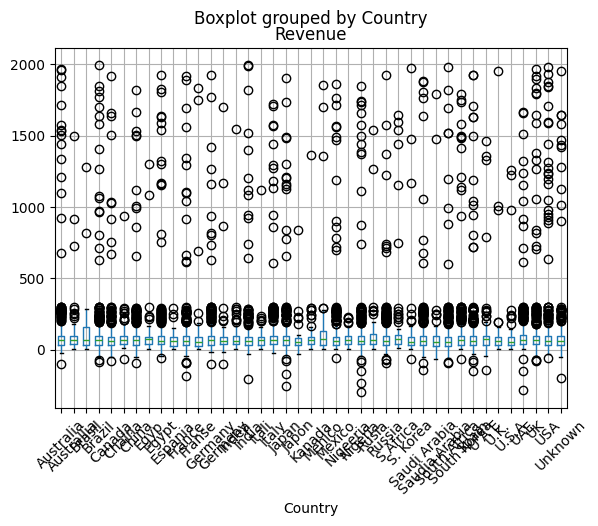

In [3]:
pop_score = pd.to_numeric(df['Popularity_Score'], errors='coerce')
pop_score.plot(kind='hist', bins=30)
plt.show()

episodes = pd.to_numeric(df['Avg_Episodes_Watched_Per_Year'], errors='coerce')
episodes.groupby(df['Character']).mean().plot(kind='bar')
plt.show()

revenue = pd.to_numeric(df['Merchandise_Revenue_MillionUSD'], errors='coerce')
temp_df = pd.DataFrame({'Revenue': revenue, 'Country': df['Country']})
temp_df.boxplot(column='Revenue', by='Country')
plt.xticks(rotation=45)
plt.show()

Task 1.3 Data Quality Issues

The data types for popularity score, average episodes, and merchandise revenue are strings instead of numbers because they contain text like Unknown.

There are missing values in the country, popularity score, and episodes columns.

The character and country text columns have inconsistent capitalization and extra spaces.

There are also extreme outliers in the revenue data.

Part 2 Data Cleaning and Preprocessing

Task 2.1 Handling Missing Values

In [4]:
df['Popularity_Score'] = pd.to_numeric(df['Popularity_Score'], errors='coerce')
df['Avg_Episodes_Watched_Per_Year'] = pd.to_numeric(df['Avg_Episodes_Watched_Per_Year'], errors='coerce')
df['Merchandise_Revenue_MillionUSD'] = pd.to_numeric(df['Merchandise_Revenue_MillionUSD'], errors='coerce')

df['Country'] = df['Country'].fillna(df['Country'].mode()[0])
df['Popularity_Score'] = df['Popularity_Score'].fillna(df['Popularity_Score'].median())
df['Avg_Episodes_Watched_Per_Year'] = df['Avg_Episodes_Watched_Per_Year'].fillna(df['Avg_Episodes_Watched_Per_Year'].median())
df['Merchandise_Revenue_MillionUSD'] = df['Merchandise_Revenue_MillionUSD'].fillna(df['Merchandise_Revenue_MillionUSD'].median())

Task 2.2 Handling Inconsistent Data

In [5]:
df['Character'] = df['Character'].astype(str).str.strip().str.title()
df['Country'] = df['Country'].astype(str).str.strip().str.title()

Task 2.3 Outlier Detection and Handling

In [6]:
columns_to_cap = ['Popularity_Score', 'Avg_Episodes_Watched_Per_Year', 'Merchandise_Revenue_MillionUSD']

for col in columns_to_cap:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    
    df[col] = np.where(df[col] < lower_limit, lower_limit, df[col])
    df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])

Task 2.4 Data Transformation

In [7]:
scaler = StandardScaler()
df['Pop_Score_Scaled'] = scaler.fit_transform(df[['Popularity_Score']])
df['Avg_Episodes_Scaled'] = scaler.fit_transform(df[['Avg_Episodes_Watched_Per_Year']])
df['Merch_Rev_Scaled'] = scaler.fit_transform(df[['Merchandise_Revenue_MillionUSD']])

Part 3 Advanced Analysis

Task 3.1 Variance Inflation Factor

In [8]:
X = df[['Pop_Score_Scaled', 'Avg_Episodes_Scaled', 'Merch_Rev_Scaled']]
X_with_const = sm.add_constant(X)

vif_df = pd.DataFrame()
vif_df["Feature"] = X_with_const.columns
vif_df["VIF"] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]
display(vif_df)

,Feature,VIF
0,const,1.000000
1,Pop_Score_Scaled,1.000557
2,Avg_Episodes_Scaled,1.000408
3,Merch_Rev_Scaled,1.000302


Task 3.2 Principal Component Analysis

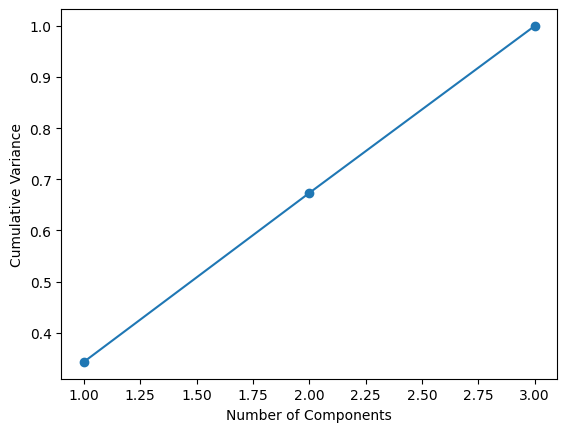

In [9]:
pca = PCA()
pca.fit(X)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.plot([1, 2, 3], cumulative_variance, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.show()

Task 4.2 Save Your Cleaned Dataset

In [10]:
# Save the cleaned and preprocessed dataset
df.to_csv('cartoon_popularity_cleaned.csv', index=False)

Part 4 Project Summary

The data initially had wrong data types because of text values like Unknown in numeric columns. I converted these to numeric types and filled the missing categorical values with the mode and numerical missing values with the median.

I cleaned the text columns by removing extra spaces and making them titlecase.

I capped the extreme outliers using the IQR method so we do not lose data. Then I scaled the numeric columns using StandardScaler.

The VIF analysis showed that the features are independent because the values are near 1. The PCA showed how much variance is kept as we add more components. The data is now clean and ready for models.